In [ ]:
# fitting
!git clone https://github.com/kaifengZheng/Zanes.git

In [ ]:
import pprint
pprint.pprint(report)

In [ ]:
exp_data.plot_fitting_results(dset,d_range=[0,10])

# dataprocessing

In [1]:
import numpy as np
import pandas as pd
from zanes.data_analysis import data_processing as dp
from zanes.data_analysis import zanes_data_analysis as zda
from glob import glob
import toml
import matplotlib.pyplot as plt


filename='test_data/pd.prj'
exp_data=zda(filename,datatype='Athena',batch_size=None,read_range=None)

In [2]:
exp_data.data

[<Group 0x7e0cc54df110>, <Group 0x7e0cc54de650>, <Group 0x7e0cc54dec90>]

In [3]:
data_param={'pre_start':-200,
               'pre_end':-70,
               'post_start':71,
               'post_end':800,
               'kweight':2,'rbkg':1.5,
               'E0':23457,
               'krange':[2,15]}

fit_range_param={'kmin':2,
                 'kmax':15,
                 'kw':2,
                 'dk':2,
                 'window':'hanning',
                 'rmin':1.646,
                 'rmax':3.292}

In [4]:
exp_data.process_data(data_param)

In [5]:
exp_data.data[0].e0=24357

E0=24356.6


24356.6

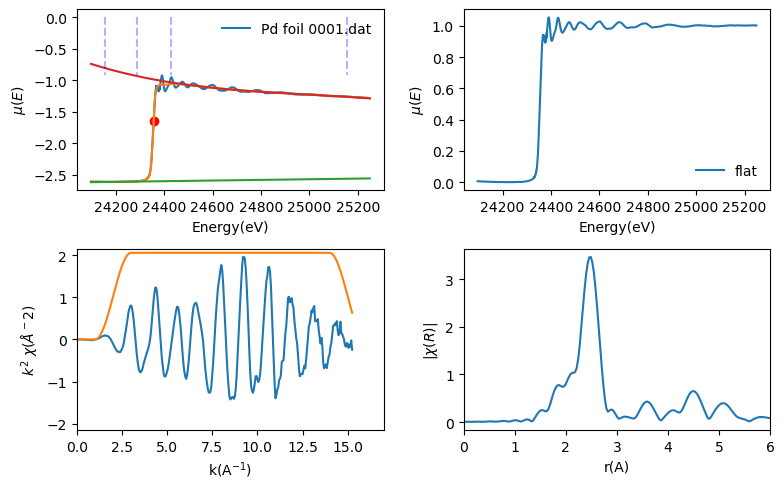

In [7]:
aa=dp(exp_data.data[1],e0=24357.4,pre_start=data_param['pre_start'],
                      pre_end=data_param['pre_end'],
               post_start=data_param['post_start'],
               post_end=data_param['post_end'],
               kweight=data_param['kweight'],rbkg=data_param['rbkg'],
               krange=data_param['krange'],plot=True)
exp_data.data[1].e0

In [7]:

filenames=glob('deglitch_pt/*.dat')
# basename(filenames[0])
filenames

['deglitch_pt/Deglitched_Elec_-0.5V_-0.19V.dat',
 'deglitch_pt/Deglitched_Amm_-0.5-0.19V.dat',
 'deglitch_pt/Deglitched_Elec_-0.9V_-0.19V.dat',
 'deglitch_pt/Deglitched_Vul_amm_ME-0.9V_-0.11V_sam_matrix_Both.dat']

In [4]:
from os.path import join,exists,basename,exists
from os import makedirs
exists(join('feff','files.dat'))

False

In [3]:
data_param={'pre_start':-350,
               'pre_end':-70,
               'post_start':71,
               'post_end':1450,
               'kweight':2,'rbkg':1,
               'E0':11563.5,
               'krange':[2,15]}
param_dict={
    'SO2':{"SO2":{'initial':0.84,'vary':False,'global':False}},
    'dele':{'dele_Pt':{'initial':0.0,'vary':True,'global':False}},
    'ss2':{'ss2_Pt':{'initial':0.0024,'vary':True,'global':False,
                    'thermal':{'type':False,
                     'theta':{'initial':400,'vary':True,'global':True}}}},
    'N':{'N_Pt':{'initial':12.0,'vary':True,'global':False}},
    'delr':{'delr_Pt':{'initial':0.0,'vary':True,'global':False}},
}

fit_range_param={'kmin':2,
                 'kmax':15,
                 'kw':2,
                 'dk':2,
                 'window':'hanning',
                 'rmin':1.646,
                 'rmax':3.292}

# for file in filenames:
file_name=basename(filenames[3])
foldername=join('results',file_name[:-4]+'rbkg1')
if not exists(foldername):
    makedirs(foldername)
exp_data=zda(filenames[3],datatype='ProQEXAFS',batch_size=1)
exp_data.process_data(data_param)
save_path=join(foldername,file_name[:-4]+'_rbkg1.txt')
dset,out,report,path=exp_data.run_fit_batch(param_dict=param_dict,fit_range_param=fit_range_param,fitpath_num=[0],feff_folder='feff',save_name=save_path,mpi=False,core=10,write=True)
report_sort=exp_data.write_sorted_report(out,report,param_dict,path[0])
exp_data.write_fitted_data(dset,filenames[3],foldername,suffix='_rbkg1')

output_fit = join(foldername,file_name[:-4]+'_rbkg1.toml')
with open(output_fit, "w") as f:
    toml.dump(report_sort,f)
    

NameError: name 'basename' is not defined

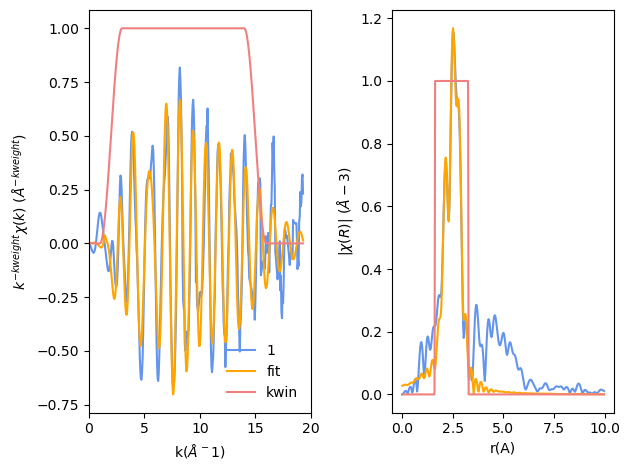

In [10]:
exp_data.plot_fitting_batch_results(2,dset,d_range=[0,1])

# plot data

ValueError: 'c1' is not a valid value for color

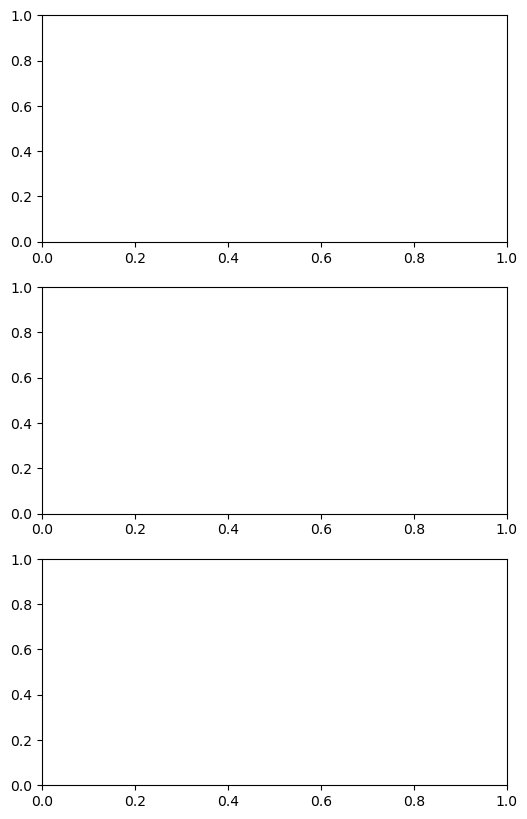

In [12]:
import toml
import matplotlib.pyplot as plt

input_file_name1 = "results/Deglitched_Elec_-0.5V_-0.19Vrbkg1/Deglitched_Elec_-0.5V_-0.19V_rbkg1.toml"
with open(input_file_name1) as toml_file:
    toml_dict1 = toml.load(toml_file)


r1=np.double(pd.DataFrame(toml_dict1['r_Pt']).loc['value'])
# r2=np.double(pd.DataFrame(toml_dict2['r']).loc['value'])
# r3=np.double(pd.DataFrame(toml_dict3['r']).loc['value'])
# r4=np.double(pd.DataFrame(toml_dict4['r']).loc['value'])
ss1=np.double(pd.DataFrame(toml_dict1['ss2_Pt']).loc['value'])
N1=np.double(pd.DataFrame(toml_dict1['N_Pt']).loc['value'])

# from pandas.core import frame

fig,ax=plt.subplots(3,1,figsize=(6,10))
time1=np.arange(0,len(r1))

ax[0].plot(time1,r1,color='c1',label='r')
ax[1].plot(time1,ss1,label='ss')
ax[2].plot(time1,N1,label='N')
# ax[1,1].plot(time4,r4,label='Deglitched_Vul_amm_ME-0.9V_-0.11V_sam_matrix_Both')
ax[0].legend(frameon=False)
ax[1].legend(frameon=False)
ax[2].legend(frameon=False)
ax[0].set_xlabel('Time')
ax[1].set_xlabel('Time')
ax[2].set_xlabel('Time')
# ax[1,1].set_xlabel('Time')
ax[0].set_ylabel('r($\AA$)')
ax[1].set_ylabel('$\sigma^2$($\AA^2$)')
ax[2].set_ylabel('CN')
# ax[1,1].set_ylabel('r($\AA$)')
# ax[0,0].set_ylim(2.74,2.76)
# ax[1,1].set_ylim(2.746,2.75)
plt.tight_layout()



In [ ]:
# pd.DataFrame(toml_dict1['r']).T.astype(float).to_csv('fitting_results_ss2_rbkg15/r/Deglitched_Amm_-0.5-0.19V.csv')
# pd.DataFrame(toml_dict2['r']).T.astype(float).to_csv('fitting_results_ss2_rbkg15/r/Deglitched_Elec_-0.5V_-0.19V.csv')
# pd.DataFrame(toml_dict3['r']).T.astype(float).to_csv('fitting_results_ss2_rbkg15/r/Deglitched_Elec_-0.9V_-0.19V.csv')
# pd.DataFrame(toml_dict4['r']).T.astype(float).to_csv('fitting_results_ss2_rbkg15/r/Deglitched_Vul_amm_ME-0.9V_-0.11V_sam_matrix_Both.csv')
# pd.DataFrame(toml_dict1['ss2']).T.astype(float).to_csv('fitting_results_ss2_rbkg15/ss2/Deglitched_Amm_-0.5-0.19V.csv')
# pd.DataFrame(toml_dict2['ss2']).T.astype(float).to_csv('fitting_results_ss2_rbkg15/ss2/Deglitched_Elec_-0.5V_-0.19V.csv')
# pd.DataFrame(toml_dict3['ss2']).T.astype(float).to_csv('fitting_results_ss2_rbkg15/ss2/Deglitched_Elec_-0.9V_-0.19V.csv')
# pd.DataFrame(toml_dict4['ss2']).T.astype(float).to_csv('fitting_results_ss2_rbkg15/ss2/Deglitched_Vul_amm_ME-0.9V_-0.11V_sam_matrix_Both.csv')

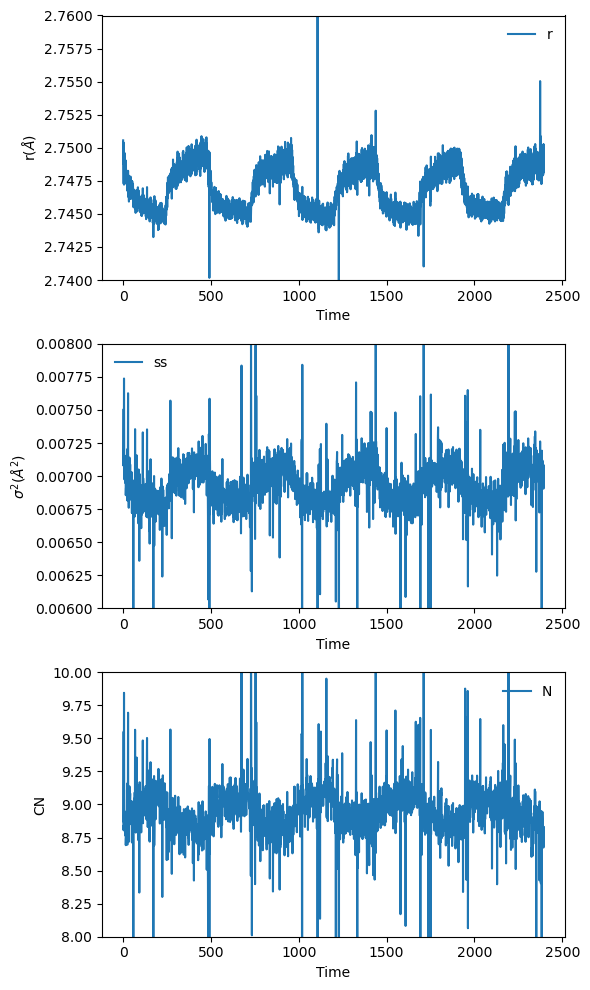

In [17]:
import toml
import matplotlib.pyplot as plt

input_file_name1 = "results/Deglitched_Amm_-0.5-0.19Vrbkg1/Deglitched_Amm_-0.5-0.19V_rbkg1.toml"
with open(input_file_name1) as toml_file:
    toml_dict1 = toml.load(toml_file)


r1=np.double(pd.DataFrame(toml_dict1['r_Pt']).loc['value'])
# r2=np.double(pd.DataFrame(toml_dict2['r']).loc['value'])
# r3=np.double(pd.DataFrame(toml_dict3['r']).loc['value'])
# r4=np.double(pd.DataFrame(toml_dict4['r']).loc['value'])
ss1=np.double(pd.DataFrame(toml_dict1['ss2_Pt']).loc['value'])
N1=np.double(pd.DataFrame(toml_dict1['N_Pt']).loc['value'])

# from pandas.core import frame

fig,ax=plt.subplots(3,1,figsize=(6,10))
time1=np.arange(0,len(r1))
ax[0].plot(time1,r1,label='r')
ax[1].plot(time1,ss1,label='ss')
ax[2].plot(time1,N1,label='N')
# ax[1,1].plot(time4,r4,label='Deglitched_Vul_amm_ME-0.9V_-0.11V_sam_matrix_Both')
ax[0].legend(frameon=False)
ax[1].legend(frameon=False)
ax[2].legend(frameon=False)
ax[0].set_xlabel('Time')
ax[1].set_xlabel('Time')
ax[2].set_xlabel('Time')
# ax[1,1].set_xlabel('Time')
ax[0].set_ylabel('r($\AA$)')
ax[1].set_ylabel('$\sigma^2$($\AA^2$)')
ax[2].set_ylabel('CN')
# ax[1,1].set_ylabel('r($\AA$)')
ax[0].set_ylim(2.74,2.76)
ax[1].set_ylim(0.006,0.008)
ax[2].set_ylim(8,10)
plt.tight_layout()

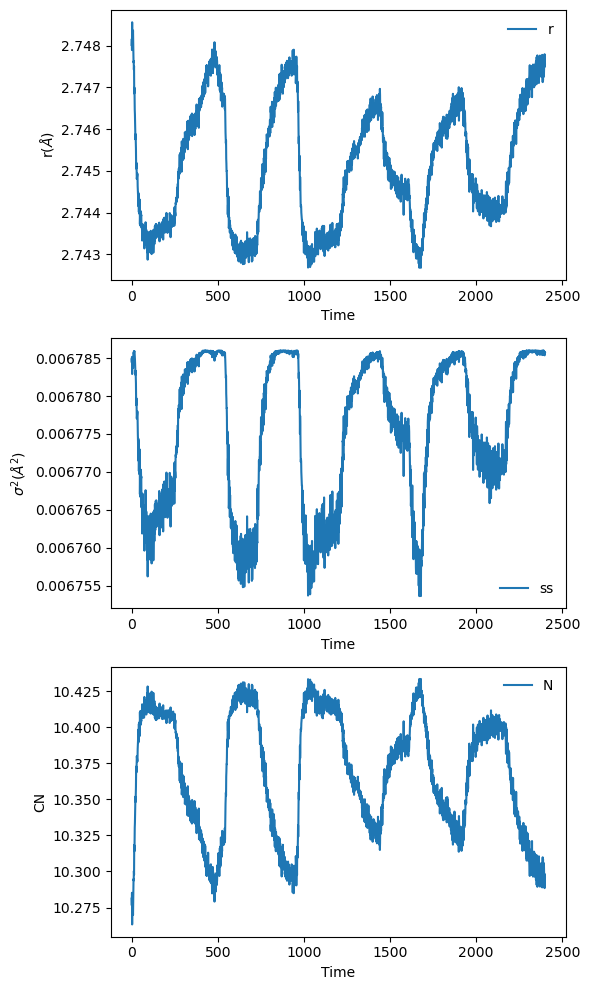

In [27]:
import toml
import matplotlib.pyplot as plt

input_file_name1 = "results/Deglitched_Elec_-0.5V_-0.19Vrbkg1/Deglitched_Elec_-0.5V_-0.19V_rbkg1.toml"
with open(input_file_name1) as toml_file:
    toml_dict1 = toml.load(toml_file)


r1=np.double(pd.DataFrame(toml_dict1['r_Pt']).loc['value'])
# r2=np.double(pd.DataFrame(toml_dict2['r']).loc['value'])
# r3=np.double(pd.DataFrame(toml_dict3['r']).loc['value'])
# r4=np.double(pd.DataFrame(toml_dict4['r']).loc['value'])
ss1=np.double(pd.DataFrame(toml_dict1['ss2_Pt']).loc['value'])
N1=np.double(pd.DataFrame(toml_dict1['N_Pt']).loc['value'])

# from pandas.core import frame

fig,ax=plt.subplots(3,1,figsize=(6,10))
time1=np.arange(0,len(r1))

ax[0].plot(time1,r1,label='r')
ax[1].plot(time1,ss1,label='ss')
ax[2].plot(time1,N1,label='N')
# ax[1,1].plot(time4,r4,label='Deglitched_Vul_amm_ME-0.9V_-0.11V_sam_matrix_Both')
ax[0].legend(frameon=False)
ax[1].legend(frameon=False)
ax[2].legend(frameon=False)
ax[0].set_xlabel('Time')
ax[1].set_xlabel('Time')
ax[2].set_xlabel('Time')
# ax[1,1].set_xlabel('Time')
ax[0].set_ylabel('r($\AA$)')
ax[1].set_ylabel('$\sigma^2$($\AA^2$)')
ax[2].set_ylabel('CN')
# ax[1,1].set_ylabel('r($\AA$)')
# ax[0,0].set_ylim(2.74,2.76)
# ax[1,1].set_ylim(2.746,2.75)
plt.tight_layout()


In [ ]:

fig,ax=plt.subplots(2,2,figsize=(10,6))
time1=np.arange(0,len(r1))
time2=np.arange(0,len(r2))
time3=np.arange(0,len(r3))
time4=np.arange(0,len(r4))
ax[0,0].plot(time1,N1,label='Deglitched_Amm_-0.5-0.19V')
ax[0,1].plot(time2,N2,label='Deglitched_Elec_-0.5V_-0.19V')
ax[1,0].plot(time3,N3,label='Deglitched_Elec_-0.9V_-0.19V')
ax[1,1].plot(time4,N4,label='Deglitched_Vul_amm_ME-0.9V_-0.11V_sam_matrix_Both')
ax[0,0].legend(frameon=False)
ax[0,1].legend(frameon=False)
ax[1,0].legend(frameon=False)
ax[1,1].legend(frameon=False)
ax[0,0].set_xlabel('Time')
ax[0,1].set_xlabel('Time')
ax[1,0].set_xlabel('Time')
ax[1,1].set_xlabel('Time')
ax[0,0].set_ylabel('$\sigma^2(\AA^2)$',fontsize=12)
ax[0,1].set_ylabel('$\sigma^2(\AA^2)$', fontsize=12)
ax[1,0].set_ylabel('$\sigma^2(\AA^2)$', fontsize=12)
ax[1,1].set_ylabel('$\sigma^2(\AA^2)$', fontsize=12)
ax[0,0].set_ylim(0.0065,0.0075)
ax[1,1].set_ylim(0.0058,0.00675)
plt.tight_layout()

In [ ]:

fig,ax=plt.subplots(2,2,figsize=(10,6))
time1=np.arange(0,len(r1))
time2=np.arange(0,len(r2))
time3=np.arange(0,len(r3))
time4=np.arange(0,len(r4))
ax[0,0].plot(time1,N1,label='Deglitched_Amm_-0.5-0.19V')
ax[0,1].plot(time2,N2,label='Deglitched_Elec_-0.5V_-0.19V')
ax[1,0].plot(time3,N3,label='Deglitched_Elec_-0.9V_-0.19V')
ax[1,1].plot(time4,N4,label='Deglitched_Vul_amm_ME-0.9V_-0.11V_sam_matrix_Both')
ax[0,0].legend(frameon=False)
ax[0,1].legend(frameon=False)
ax[1,0].legend(frameon=False)
ax[1,1].legend(frameon=False)
ax[0,0].set_xlabel('Time')
ax[0,1].set_xlabel('Time')
ax[1,0].set_xlabel('Time')
ax[1,1].set_xlabel('Time')
ax[0,0].set_ylabel('$\sigma^2(\AA^2)$',fontsize=12)
ax[0,1].set_ylabel('$\sigma^2(\AA^2)$', fontsize=12)
ax[1,0].set_ylabel('$\sigma^2(\AA^2)$', fontsize=12)
ax[1,1].set_ylabel('$\sigma^2(\AA^2)$', fontsize=12)
ax[0,0].set_ylim(0.0065,0.0075)
ax[1,1].set_ylim(0.0058,0.00675)
plt.tight_layout()

# error analysis

E0=11563.5


Attribute,Type
energy,ndarray
mu,ndarray
label,int


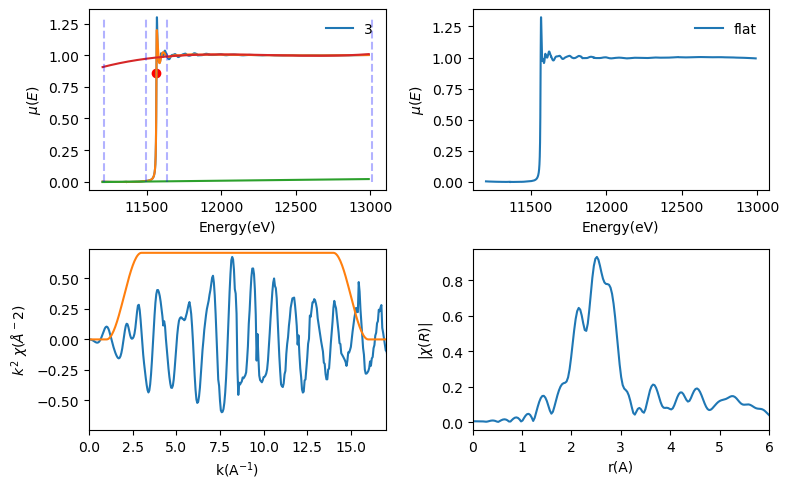

In [15]:
from re import match
input_file="results/Deglitched_Elec_-0.5V_-0.19Vrbkg1/Deglitched_Elec_-0.5V_-0.19V_rbkg1.txt"
r_factor_ss=[]
reduced_chi_ss=[]
with open(input_file) as file1:
    data=file1.readlines()
for i in range(len(data)):
    if match('\ +r-factor\ +=\ +(\d+.?\d+)',data[i]):
        r_factor_ss.append(np.float32(match('\ +r-factor\ +=\ +(\d+.?\d+)',data[i]).group(1)))
    if match('\ +reduced chi_square\ +=\ +(\d.?\d+)',data[i]):
        reduced_chi_ss.append(np.float32(match('\ +reduced chi_square\ +=\ +(\d+.?\d+)',data[i]).group(1)))


# input_file="fitting_results_ss2/raw fitting results/Deglitched_Amm_-0.5-0.19V.txt"
# r_factor_p_ss=[]
# reduced_chi_p_ss=[]
# with open(input_file) as file1:
#     data=file1.readlines()
# for i in range(len(data)):
#     if match('\ +r-factor\ +=\ +(\d+.?\d+)',data[i]):
#         r_factor_p_ss.append(np.float32(match('\ +r-factor\ +=\ +(\d+.?\d+)',data[i]).group(1)))
#     if match('\ +reduced chi_square\ +=\ +(\d.?\d+)',data[i]):
#         reduced_chi_p_ss.append(np.float32(match('\ +reduced chi_square\ +=\ +(\d+.?\d+)',data[i]).group(1)))
# data

In [ ]:

# input_file="fitting_results/raw fitting results/Deglitched_Amm_-0.5-0.19V.txt"
# r_factor=[]
# reduced_chi=[]
# with open(input_file) as file1:
#     data=file1.readlines()
# for i in range(len(data)):
#     if match('\ +r-factor\ +=\ +(\d+.?\d+)',data[i]):
#         r_factor.append(np.float32(match('\ +r-factor\ +=\ +(\d+.?\d+)',data[i]).group(1)))
#     if match('\ +reduced chi_square\ +=\ +(\d.?\d+)',data[i]):
#         reduced_chi.append(np.float32(match('\ +reduced chi_square\ +=\ +(\d+.?\d+)',data[i]).group(1)))



WARNING [2024-03-26 21:35:20]: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
WARNING [2024-03-26 21:35:20]: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


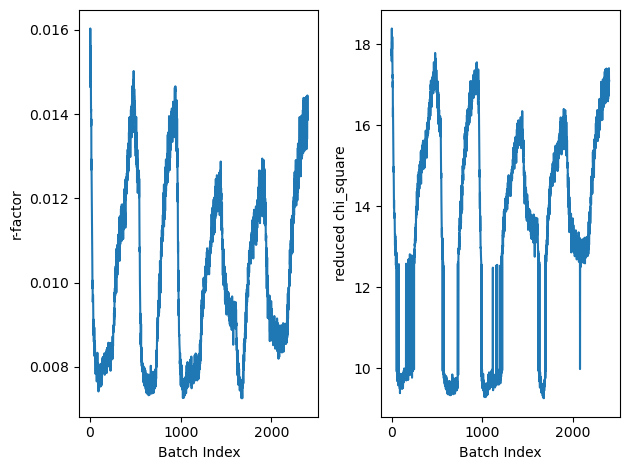

In [19]:
fig,ax=plt.subplots(1,2)
batch_index=np.arange(0,len(r_factor_ss))
ax[0].plot(batch_index,r_factor_ss)

ax[1].plot(batch_index,reduced_chi_ss)

ax[0].set_xlabel('Batch Index')
ax[1].set_xlabel('Batch Index')
ax[0].set_ylabel('r-factor')
ax[1].set_ylabel('reduced chi_square')
ax[0].legend(frameon=False)
ax[1].legend(frameon=False)
plt.tight_layout()

In [ ]:

input_file="fitting_results/raw fitting results/Deglitched_Amm_-0.5-0.19V.txt"
r_factor=[]
reduced_chi=[]
with open(input_file) as file1:
    data=file1.readlines()
for i in range(len(data)):
    if match('\ +r-factor\ +=\ +(\d+.?\d+)',data[i]):
        r_factor.append(np.float32(match('\ +r-factor\ +=\ +(\d+.?\d+)',data[i]).group(1)))
    if match('\ +reduced chi_square\ +=\ +(\d.?\d+)',data[i]):
        reduced_chi.append(np.float32(match('\ +reduced chi_square\ +=\ +(\d+.?\d+)',data[i]).group(1)))
fig,ax=plt.subplots(1,2)
batch_index=np.arange(0,len(r_factor))
ax[0].plot(batch_index,r_factor,label='CN global=False')
ax[0].plot(batch_index,r_factor_ss,label='CN global=True')
ax[1].plot(batch_index,reduced_chi,label='CN global=False')
ax[1].plot(batch_index,reduced_chi_ss,label='CN global=True')
ax[0].set_xlabel('Batch Index')
ax[1].set_xlabel('Batch Index')
ax[0].set_ylabel('r-factor')
ax[1].set_ylabel('reduced chi_square')
ax[0].legend(frameon=False)
ax[1].legend(frameon=False)
plt.tight_layout()


In [ ]:
import toml
import matplotlib.pyplot as plt
input_file_name1 = "fitting_results/raw fitting results/Deglitched_Amm_-0.5-0.19V.toml"
input_file_name2 = "fitting_results/raw fitting results/Deglitched_Elec_-0.5V_-0.19V.toml"
input_file_name3 = "fitting_results/raw fitting results/Deglitched_Elec_-0.9V_-0.19V.toml"
input_file_name4 = "fitting_results/raw fitting results/Deglitched_Vul_amm_ME-0.9V_-0.11V_sam_matrix_Both.toml"
with open(input_file_name1) as toml_file:
    toml_dict1 = toml.load(toml_file)
with open(input_file_name2) as toml_file:
    toml_dict2 = toml.load(toml_file)
with open(input_file_name3) as toml_file:
    toml_dict3 = toml.load(toml_file)
with open(input_file_name4) as toml_file:
    toml_dict4 = toml.load(toml_file)

r1=np.double(pd.DataFrame(toml_dict1['r']).loc['value'])
r2=np.double(pd.DataFrame(toml_dict2['r']).loc['value'])
r3=np.double(pd.DataFrame(toml_dict3['r']).loc['value'])
r4=np.double(pd.DataFrame(toml_dict4['r']).loc['value'])
N1=np.double(pd.DataFrame(toml_dict1['N']).loc['value'])
N2=np.double(pd.DataFrame(toml_dict2['N']).loc['value'])
N3=np.double(pd.DataFrame(toml_dict3['N']).loc['value'])
N4=np.double(pd.DataFrame(toml_dict4['N']).loc['value'])

In [ ]:
fig,ax=plt.subplots(2,2,figsize=(10,6))
time1=np.arange(0,len(r1))
time2=np.arange(0,len(r2))
time3=np.arange(0,len(r3))
time4=np.arange(0,len(r4))
ax[0,0].plot(time1,r1,label='Deglitched_Amm_-0.5-0.19V')
ax[0,1].plot(time2,r2,label='Deglitched_Elec_-0.5V_-0.19V')
ax[1,0].plot(time3,r3,label='Deglitched_Elec_-0.9V_-0.19V')
ax[1,1].plot(time4,r4,label='Deglitched_Vul_amm_ME-0.9V_-0.11V_sam_matrix_Both')
ax[0,0].legend(frameon=False)
ax[0,1].legend(frameon=False)
ax[1,0].legend(frameon=False)
ax[1,1].legend(frameon=False)
ax[0,0].set_xlabel('Time')
ax[0,1].set_xlabel('Time')
ax[1,0].set_xlabel('Time')
ax[1,1].set_xlabel('Time')
ax[0,0].set_ylabel('r($\AA$)')
ax[0,1].set_ylabel('r($\AA$)')
ax[1,0].set_ylabel('r($\AA$)')
ax[1,1].set_ylabel('r($\AA$)')
ax[0,0].set_ylim(2.74,2.76)
ax[1,1].set_ylim(2.746,2.75)
plt.tight_layout()

In [ ]:

fig,ax=plt.subplots(2,2,figsize=(10,6))
time1=np.arange(0,len(r1))
time2=np.arange(0,len(r2))
time3=np.arange(0,len(r3))
time4=np.arange(0,len(r4))
ax[0,0].plot(time1,N1,label='Deglitched_Amm_-0.5-0.19V')
ax[0,1].plot(time2,N2,label='Deglitched_Elec_-0.5V_-0.19V')
ax[1,0].plot(time3,N3,label='Deglitched_Elec_-0.9V_-0.19V')
ax[1,1].plot(time4,N4,label='Deglitched_Vul_amm_ME-0.9V_-0.11V_sam_matrix_Both')
ax[0,0].legend(frameon=False)
ax[0,1].legend(frameon=False)
ax[1,0].legend(frameon=False)
ax[1,1].legend(frameon=False)
ax[0,0].set_xlabel('Time')
ax[0,1].set_xlabel('Time')
ax[1,0].set_xlabel('Time')
ax[1,1].set_xlabel('Time')
ax[0,0].set_ylabel('$CN$',fontsize=12)
ax[0,1].set_ylabel('$CN$', fontsize=12)
ax[1,0].set_ylabel('$CN$', fontsize=12)
ax[1,1].set_ylabel('$CN$', fontsize=12)
ax[0,0].set_ylim(8.3,9.5)
ax[1,1].set_ylim(9.2,10.4)
plt.tight_layout()

In [ ]:
exp_data.plot_fitting_results(dset,d_range=[0,10])

In [ ]:
from larch.io import read_athena
from copy import deepcopy
from larch.io import read_athena
from larch.xafs import find_e0,pre_edge, autobk, xftf, xftr
from larch import Group
from larch.io import read_athena
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
import pandas as pd
from math import pi
from Zanes.data_analysis import data_analysis

In [ ]:
%matplotlib widget

In [ ]:
test_data=read_athena('test\\NormE of MEs from reconstructed data (1).prj')
test_group=test_data['Pt_foil_ref_dat']

In [ ]:
data_analysis(test_group,pre_start=-300,pre_end=-50,post_start=20,post_end=1300,kweight=2,krange=[2,14],rbkg=1.1,plot=True)

In [ ]:
from larch.xafs.feffit import feffit_transform,feffit_dataset,feffit,feffit_report
from larch.fitting import param,param_group
from larch.xafs import feffpath
from larch.wxlib.xafsplots import plot_chifit


In [ ]:
pars=param_group(so2=param(0.84,vary=False),
                 dele=param(0.0,vary=True),
                 ss2=param(0.003,vary=True),
                 delr=param(0.0,vary=True),
                 N=param(12.0,vary=True))
path1 = feffpath('feff/feff0001.dat',
                 s02=1, 
                 degen='N*so2',
                 e0='dele', 
                 sigma2='ss2', 
                 deltar='delr')
trans = feffit_transform(kmin=2, kmax=11, kw=2, dk=2, window='hanning', rmin=1.4, rmax=3.38)
dset = feffit_dataset(data=a, pathlist=[path1], transform=trans)
out = feffit(pars, dset)
# print(feffit_report(out))
# out.datasets
# plot_chifit(dset)


In [ ]:
out.params

In [ ]:
mod=dset.model
dat=dset.data
data_chik=dat.chi*dat.k**2
model_chik=mod.chi*mod.k**2
fig,ax=plt.subplots(1,2)
ax[0].plot(dat.k,data_chik)
# ax[0].plot(mod.k,model_chik)
ax[1].plot(dat.r,dat.chir_mag)
ax[1].plot(mod.r,mod.chir_mag)
ax[0].set_xlim(0,20)
plt.show()  

In [ ]:
# test